# 🎯 **Feature Engineering: Resampling & Encoding**

## 📘 **Telco Customer Churn Analizi - YBS Perspektifi**

Bu notebook, **dengesiz veri setleri** ve **kategorik değişken dönüşümleri** konularında YBS öğrencilerine yönelik kapsamlı bir rehberdir. Telco müşteri kayıp (churn) verisi üzerinden gerçek iş senaryolarıyla öğreneceğiz.

### 🎓 **Öğrenme Hedefleri**

- Dengesiz veri setlerinin iş hedefleri üzerindeki etkisini anlamak
- Upsampling, Downsampling ve SMOTE tekniklerini uygulamak
- Farklı encoding yöntemlerinin (One-Hot, Label, Ordinal, Frequency, Target) mantığını kavramak
- Train-test ayrımı sırasında data leakage'ı önlemek
- İş hedefleriyle uyumlu metrik seçimi yapmak

## 1️⃣ **Kütüphaneler ve Veri Yükleme**

### 📚 **Gerekli Kütüphaneler**

Analiz için temel Python kütüphanelerini import ediyoruz:

In [1]:
# Veri işleme ve analiz kütüphaneleri
import pandas as pd
import numpy as np

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Makine öğrenmesi ve veri hazırlama
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Resampling kütüphaneleri (imbalanced-learn)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Uyarıları filtreleme
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("pastel")

# Rastgelelik kontrolü için seed (tekrar üretilebilirlik)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"🎲 Random Seed: {RANDOM_SEED}")

✅ Tüm kütüphaneler başarıyla yüklendi!
🎲 Random Seed: 42


### 💡 **Random Seed Nedir?**

**Random seed**, rastgele işlemlerin tekrar üretilebilir olmasını sağlar. Bilgisayar gerçek rastgelelik üretmez; bir algoritma ile psödo-rastgele sayılar üretir. Seed, bu algoritmanın başlangıç noktasını sabitler.

**Günlük Benzetme:** Aynı tarife ile aynı malzemeleri ölçerek yemek yapmak gibi; ölçü olmazsa her seferinde tadı değişir.

**YBS İçin Önemi:** 
- Raporlanabilirlik ve denetlenebilirlik sağlar
- İki farklı analistin aynı sonucu üretmesini garanti eder
- Balancing işlemlerinde "hangi satırların seçildiği" sonuçları etkiler

### 📂 Veri Setini Yükleme

In [2]:
# Telco Customer Churn veri setini yükle
df = pd.read_csv('Telco-Customer-Churn.csv')

print("📊 Veri Seti Bilgileri")
print("=" * 50)
print(f"Satır sayısı: {df.shape[0]:,}")
print(f"Sütun sayısı: {df.shape[1]}")
print(f"Toplam gözlem: {df.shape[0] * df.shape[1]:,}")

📊 Veri Seti Bilgileri
Satır sayısı: 7,043
Sütun sayısı: 21
Toplam gözlem: 147,903


In [3]:
# İlk 5 satıra göz atalım
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2️⃣ **Veri Keşfi ve İlk Analizler**

### 🔍 Veri Yapısı İncelemesi

In [4]:
# Sütun tipleri ve eksik değer kontrolü
print("📋 Sütun Bilgileri")
print("=" * 70)
df.info()

📋 Sütun Bilgileri
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [5]:
# Sayısal değişkenlerin istatistiksel özeti
print("📊 Sayısal Değişkenlerin İstatistiksel Özeti")
print("=" * 70)
df.describe().T

📊 Sayısal Değişkenlerin İstatistiksel Özeti


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [6]:
# Kategorik değişkenlerin benzersiz değer sayıları
print("🏷️ Kategorik Değişkenler ve Benzersiz Değer Sayıları")
print("=" * 70)

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col:20} → {unique_count:2} benzersiz değer")
    if unique_count <= 5:
        print(f"  Değerler: {df[col].unique().tolist()}")
    print()

🏷️ Kategorik Değişkenler ve Benzersiz Değer Sayıları
customerID           → 7043 benzersiz değer

gender               →  2 benzersiz değer
  Değerler: ['Female', 'Male']

Partner              →  2 benzersiz değer
  Değerler: ['Yes', 'No']

Dependents           →  2 benzersiz değer
  Değerler: ['No', 'Yes']

PhoneService         →  2 benzersiz değer
  Değerler: ['No', 'Yes']

MultipleLines        →  3 benzersiz değer
  Değerler: ['No phone service', 'No', 'Yes']

InternetService      →  3 benzersiz değer
  Değerler: ['DSL', 'Fiber optic', 'No']

OnlineSecurity       →  3 benzersiz değer
  Değerler: ['No', 'Yes', 'No internet service']

OnlineBackup         →  3 benzersiz değer
  Değerler: ['Yes', 'No', 'No internet service']

DeviceProtection     →  3 benzersiz değer
  Değerler: ['No', 'Yes', 'No internet service']

TechSupport          →  3 benzersiz değer
  Değerler: ['No', 'Yes', 'No internet service']

StreamingTV          →  3 benzersiz değer
  Değerler: ['No', 'Yes', 'No internet

### 🎯 **Hedef Değişken (Target) Hakkında**

**Churn** değişkenimiz:
- **Yes**: Müşteri ayrıldı (kaybedildi)
- **No**: Müşteri kaldı (aktif)

**İş Hedefi:** Ayrılma riski yüksek müşterileri önceden tespit ederek elde tutma kampanyaları düzenlemek.

## 3️⃣ **Veri Temizliği**

### 🧹 **TotalCharges Problemi**

Telco veri setinde sık karşılaşılan bir problem: **TotalCharges** sütunu sayısal olması gerekirken **object** tipinde geliyor. Bunun nedeni bazı kayıtlarda boşluk karakteri olmasıdır.

In [7]:
# TotalCharges sütununun tipini kontrol edelim
print("🔍 TotalCharges Sütun Tipi Kontrolü")
print("=" * 50)
print(f"Mevcut veri tipi: {df['TotalCharges'].dtype}")
print(f"\nİlk 10 değer:")
print(df['TotalCharges'].head(10))

🔍 TotalCharges Sütun Tipi Kontrolü
Mevcut veri tipi: object

İlk 10 değer:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [8]:
# Boşluk karakteri içeren kayıtları bulalım
print("🔎 Boşluk İçeren Kayıtları Tespit Ediyoruz...")
print("=" * 50)

# TotalCharges'da boşluk olan satırlar
space_mask = df['TotalCharges'] == ' '
problematic_rows = df[space_mask]

print(f"Boşluk içeren satır sayısı: {problematic_rows.shape[0]}")
print(f"\nBu satırların özellikleri:")
print(problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head())

🔎 Boşluk İçeren Kayıtları Tespit Ediyoruz...
Boşluk içeren satır sayısı: 11

Bu satırların özellikleri:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             


### 💡**Temizleme Stratejisi**

**Gözlem:** Boşluk içeren kayıtlar genellikle yeni müşterilerdir (tenure = 0). Bu müşterilerin henüz ödeme yapmadığı için TotalCharges boş bırakılmış.

**Karar:** 
- Boşlukları **NaN** ile değiştir
- NaN değerleri **0** ile doldur (yeni müşteri = henüz toplam ödeme yok)
- TotalCharges'ı **float** tipine çevir

In [9]:
# TotalCharges temizleme işlemi
print("🧹 TotalCharges Temizleniyor...")
print("=" * 50)

# Boşlukları NaN ile değiştir
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# NaN sayısını kontrol et
nan_count = df['TotalCharges'].isna().sum()
print(f"NaN değer sayısı: {nan_count}")

# NaN'ları 0 ile doldur (yeni müşteriler için mantıklı)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Float tipine çevir
df['TotalCharges'] = df['TotalCharges'].astype(float)

print(f"\n✅ Temizleme tamamlandı!")
print(f"Yeni veri tipi: {df['TotalCharges'].dtype}")
print(f"Eksik değer var mı? {df['TotalCharges'].isna().any()}")

🧹 TotalCharges Temizleniyor...
NaN değer sayısı: 11

✅ Temizleme tamamlandı!
Yeni veri tipi: float64
Eksik değer var mı? False


### 🔍 **Genel Eksik Değer Kontrolü**

In [11]:
# Tüm sütunlarda eksik değer kontrolü
print("📊 Tüm Veri Setinde Eksik Değer Raporu")
print("=" * 50)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Eksik Sayı': missing_values,
    'Yüzde (%)': missing_percent
})

# Sadece eksik değer olanları göster
missing_df = missing_df[missing_df['Eksik Sayı'] > 0].sort_values('Eksik Sayı', ascending=False)

if missing_df.empty:
    print("✅ Hiçbir sütunda eksik değer yok!")
else:
    print(missing_df)

📊 Tüm Veri Setinde Eksik Değer Raporu
✅ Hiçbir sütunda eksik değer yok!


### 🗑️ **Gereksiz Sütunları Kaldırma**

**customerID** sütunu her satır için benzersizdir ve modelleme için bilgi içermez. Bu tür **identifier** (tanımlayıcı) sütunlar modele dahil edilmemelidir.

In [12]:
# customerID sütununu kaldır
print("🗑️ customerID Sütunu Kaldırılıyor...")
print("=" * 50)
print(f"Önceki sütun sayısı: {df.shape[1]}")

df = df.drop('customerID', axis=1)

print(f"Sonraki sütun sayısı: {df.shape[1]}")
print(f"\n✅ customerID başarıyla kaldırıldı!")
print(f"\nGüncel veri şekli: {df.shape}")

🗑️ customerID Sütunu Kaldırılıyor...
Önceki sütun sayısı: 21
Sonraki sütun sayısı: 20

✅ customerID başarıyla kaldırıldı!

Güncel veri şekli: (7043, 20)


## 4️⃣ **Target Analizi ve Dengesizlik Problemi**

### 🎯 **Churn Değişkenini İkili Forma Çevirme**

Makine öğrenmesi modelleri için hedef değişkeni sayısal forma çevirmemiz gerekiyor:

In [13]:
# Churn değişkenini 0/1 formatına çevir
print("🔄 Churn Değişkeni Dönüştürülüyor...")
print("=" * 50)

print(f"Dönüşüm öncesi değerler: {df['Churn'].unique()}")

# Yes=1, No=0 olacak şekilde dönüştür
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dönüşüm sonrası değerler: {df['Churn'].unique()}")
print(f"\n✅ Dönüşüm tamamlandı! (Yes=1, No=0)")

🔄 Churn Değişkeni Dönüştürülüyor...
Dönüşüm öncesi değerler: ['No' 'Yes']
Dönüşüm sonrası değerler: [0 1]

✅ Dönüşüm tamamlandı! (Yes=1, No=0)


### 📊 **Dengesizlik Analizi**

**Dengesiz veri seti ne demek?** Target değişkenindeki sınıflardan birinin sayıca diğerini ciddi şekilde geçmesi demektir.

In [14]:
# Target değişkenin dağılımını incele
print("📊 CHURN DAĞILIMI ANALİZİ")
print("=" * 70)

churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(f"\n{'Sınıf':<15} {'Sayı':<15} {'Yüzde':<15}")
print("-" * 45)
print(f"{'Kalmadı (0)':<15} {churn_counts[0]:<15,} {churn_percentages[0]:<15.2f}%")
print(f"{'Ayrıldı (1)':<15} {churn_counts[1]:<15,} {churn_percentages[1]:<15.2f}%")

# Dengesizlik oranı
imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\n🔍 Dengesizlik Oranı: {imbalance_ratio:.2f}:1")
print(f"   (Çoğunluk sınıfı, azınlık sınıfından {imbalance_ratio:.2f} kat daha fazla)")

📊 CHURN DAĞILIMI ANALİZİ

Sınıf           Sayı            Yüzde          
---------------------------------------------
Kalmadı (0)     5,174           73.46          %
Ayrıldı (1)     1,869           26.54          %

🔍 Dengesizlik Oranı: 2.77:1
   (Çoğunluk sınıfı, azınlık sınıfından 2.77 kat daha fazla)


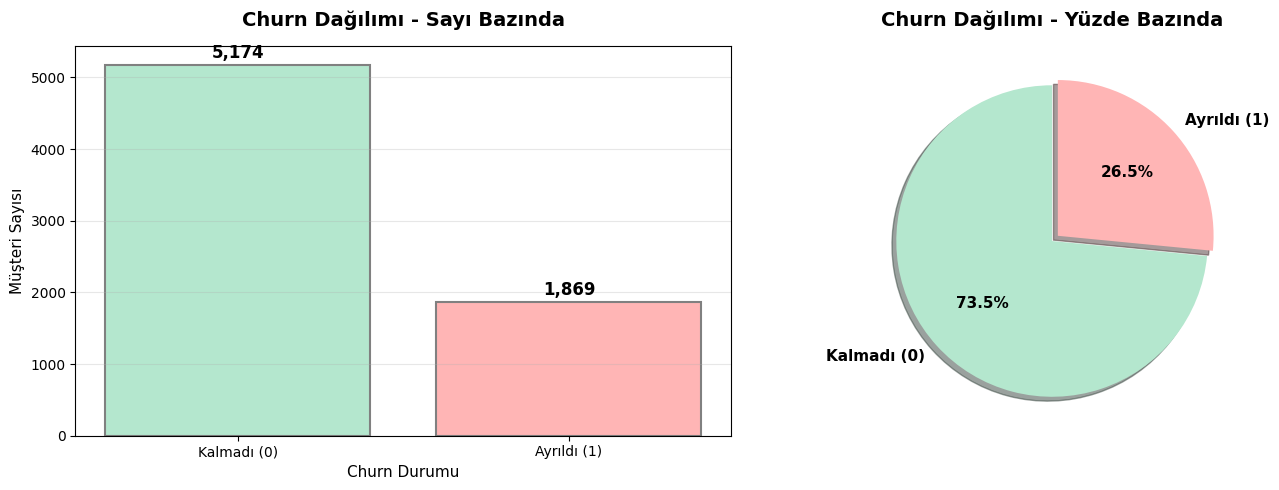

In [15]:
# Target dağılımını görselleştir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pastel renkler
colors = ['#B4E7CE', '#FFB5B5']

# Subplot 1: Sayı bazında bar plot
axes[0].bar(['Kalmadı (0)', 'Ayrıldı (1)'], churn_counts.values, color=colors, edgecolor='gray', linewidth=1.5)
axes[0].set_title('Churn Dağılımı - Sayı Bazında', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Müşteri Sayısı', fontsize=11)
axes[0].set_xlabel('Churn Durumu', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yaz
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

# Subplot 2: Yüzde bazında pie chart
axes[1].pie(churn_counts.values, labels=['Kalmadı (0)', 'Ayrıldı (1)'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Churn Dağılımı - Yüzde Bazında', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

### 💡 **YBS Perspektifi: Dengesizlik Neden Kritik?**

**İş Senaryosu:** Telco şirketinde müşteri kaybı (churn) maliyetlidir. Ayrılan bir müşteriyi yeniden kazanmak, mevcut müşteriyi tutmaktan 5-7 kat daha pahalıdır.

**Problem:** Veri setinde "ayrılmayan" çok, "ayrılan" az. Model çoğunluğu öğrenip "herkese No de" diyerek yüzde 73 doğrulukla başarılı görünebilir. **Ama ayrılacak müşterileri kaçırır!**

**Sonuç:** Kampanya bütçesi boşa gider, gerçek riskli müşteriler tespit edilemez, gelir kaybı artar.

```mermaid
flowchart TD
    A["<b>📊 Dengesiz Veri Seti</b><br/>Kalmadı: 5174 | Ayrıldı: 1869"] --> B{"<b>🤖 Model<br/>Öğrenme Süreci</b>"}
    
    B --> C["<b>❌ Yanlış Yaklaşım</b><br/>Sadece accuracy'ye bak"]
    B --> D["<b>✅ Doğru Yaklaşım</b><br/>Recall & Precision'a bak"]
    
    C --> E["<b>🎯 Model Stratejisi</b><br/>'Herkese No De'"]
    E --> F["<b>📈 Sonuç</b><br/>Accuracy: %73<br/>Ama ayrılanları kaçır!"]
    F --> G["<b>💸 İş Etkisi</b><br/>Kampanya başarısız<br/>Müşteri kaybı artar"]
    
    D --> H["<b>⚖️ Balancing Uygula</b><br/>Upsampling/Downsampling"]
    H --> I["<b>🎯 Doğru Metrik</b><br/>Recall, F1, ROC-AUC"]
    I --> J["<b>✨ İş Başarısı</b><br/>Riskli müşteri tespiti<br/>Hedefli kampanyalar"]
    
    style A fill:#FFE5E5,stroke:#FF6B6B,stroke-width:3px,color:#000
    style C fill:#FFD4D4,stroke:#FF4444,stroke-width:2px,color:#000
    style D fill:#D4F4DD,stroke:#4CAF50,stroke-width:2px,color:#000
    style G fill:#FFB5B5,stroke:#D32F2F,stroke-width:3px,color:#000
    style J fill:#B4E7CE,stroke:#2E7D32,stroke-width:3px,color:#000
    style E fill:#FFF4CC,stroke:#FFA726,stroke-width:2px,color:#000
    style H fill:#E1F5FE,stroke:#0288D1,stroke-width:2px,color:#000
```

### 📌 **Önemli Metrikler**

Dengesiz veri setlerinde **sadece accuracy yeterli değildir!** Aşağıdaki metriklere de bakmalıyız:

| Metrik | Açıklama | YBS İçin Anlam |
|--------|----------|----------------|
| **Recall** | Gerçek pozitif olanları yakalama oranı | Ayrılacak müşterileri kaçırmama |
| **Precision** | Pozitif dediğimizde doğru olma oranı | Kampanya hedeflemede isabet |
| **F1-Score** | Recall ve Precision'ın harmonik ortalaması | Dengeyi gösterir |
| **ROC-AUC** | Model ayırma gücünü ölçer | Genel performans |
| **PR-AUC** | Dengesiz veri için ROC'tan daha iyi | Azınlık sınıfı odaklı |

**Telco için hedef:** Yüksek Recall (ayrılanları yakalamak) + Makul Precision (kampanya maliyeti kontrol)

## 5️⃣ **Train-Test Ayrımı**

### ⚠️ **KRİTİK KURAL: Balancing'den ÖNCE Train-Test Split!**

**Neden?** Eğer balancing'i tüm veri üzerinde yaparsak **data leakage** (veri sızıntısı) riski doğar. Test setindeki bazı örnekler (veya kopyaları) eğitim setine karışır ve model "sınavı görmüş" gibi olur.

**Doğru Sıra:**
1. ✅ Train-Test Split yap
2. ✅ Sadece Train üzerinde balancing uygula
3. ✅ Test setini doğal dağılımında bırak
4. ✅ Model eğitimi ve değerlendirme

```mermaid
flowchart LR
    A["<b>📦 Tüm Veri</b><br/>7043 satır"] --> B{"<b>❌ Yanlış Yol</b><br/>Önce Balancing"}
    A --> C{"<b>✅ Doğru Yol</b><br/>Önce Split"}
    
    B --> D["<b>⚖️ Tüm veriyi<br/>balance et</b>"]
    D --> E["<b>🔀 Sonra<br/>Train-Test split</b>"]
    E --> F["<b>💥 DATA LEAKAGE!</b><br/>Test örnekleri train'de<br/>Model haksız avantaj"]
    
    C --> G["<b>🔀 Train-Test<br/>Split</b><br/>Train: 80%<br/>Test: 20%"]
    G --> H["<b>⚖️ Sadece Train'i<br/>balance et</b>"]
    H --> I["<b>Test doğal kalır</b>"]
    I --> J["<b>✨ Gerçekçi<br/>Değerlendirme</b><br/>Model gerçek dünyayı<br/>görmüş olur"]
    
    style A fill:#E1F5FE,stroke:#0288D1,stroke-width:3px,color:#000
    style B fill:#FFD4D4,stroke:#FF4444,stroke-width:2px,color:#000
    style C fill:#D4F4DD,stroke:#4CAF50,stroke-width:2px,color:#000
    style F fill:#FFB5B5,stroke:#D32F2F,stroke-width:3px,color:#000
    style J fill:#B4E7CE,stroke:#2E7D32,stroke-width:3px,color:#000
    style H fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
```

### 🔀 **Stratified Train-Test Split**

**Stratified Split:** Target değişkenin oranını hem train hem test setinde koruyarak bölme yapar. Bu dengesiz veri setlerinde çok önemlidir!

In [16]:
# X (özellikler) ve y (hedef) ayırma
print("🔀 Veriyi X ve y'e Ayırıyoruz...")
print("=" * 70)

# Hedef değişken
y = df['Churn']

# Özellikler (Churn hariç tüm sütunlar)
X = df.drop('Churn', axis=1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nX'deki sütunlar: {X.shape[1]} adet")
print(f"y'deki sınıf dağılımı:\n{y.value_counts()}")

🔀 Veriyi X ve y'e Ayırıyoruz...
X shape: (7043, 19)
y shape: (7043,)

X'deki sütunlar: 19 adet
y'deki sınıf dağılımı:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [17]:
# Stratified Train-Test Split
print("🎯 Stratified Train-Test Split Yapılıyor...")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # %20 test
    stratify=y,              # Target oranını koru
    random_state=RANDOM_SEED # Tekrar üretilebilirlik için
)

print(f"✅ Split tamamlandı!")
print(f"\n📊 Veri Boyutları:")
print(f"  Train X: {X_train.shape}")
print(f"  Test X:  {X_test.shape}")
print(f"  Train y: {y_train.shape}")
print(f"  Test y:  {y_test.shape}")

print(f"\n🎯 Train Set - Churn Dağılımı:")
train_dist = y_train.value_counts()
train_pct = y_train.value_counts(normalize=True) * 100
print(f"  Class 0 (Kaldı):  {train_dist[0]:,} ({train_pct[0]:.2f}%)")
print(f"  Class 1 (Ayrıldı): {train_dist[1]:,} ({train_pct[1]:.2f}%)")

print(f"\n🎯 Test Set - Churn Dağılımı:")
test_dist = y_test.value_counts()
test_pct = y_test.value_counts(normalize=True) * 100
print(f"  Class 0 (Kaldı):  {test_dist[0]:,} ({test_pct[0]:.2f}%)")
print(f"  Class 1 (Ayrıldı): {test_dist[1]:,} ({test_pct[1]:.2f}%)")

print(f"\n✨ Stratified split sayesinde oranlar korundu!")

🎯 Stratified Train-Test Split Yapılıyor...
✅ Split tamamlandı!

📊 Veri Boyutları:
  Train X: (5634, 19)
  Test X:  (1409, 19)
  Train y: (5634,)
  Test y:  (1409,)

🎯 Train Set - Churn Dağılımı:
  Class 0 (Kaldı):  4,139 (73.46%)
  Class 1 (Ayrıldı): 1,495 (26.54%)

🎯 Test Set - Churn Dağılımı:
  Class 0 (Kaldı):  1,035 (73.46%)
  Class 1 (Ayrıldı): 374 (26.54%)

✨ Stratified split sayesinde oranlar korundu!


## 6️⃣ **Encoding: Kategorik Değişkenleri Sayısallaştırma**

### 🔤 **Encoding Nedir?**

**Encoding**, kategorik (metin) değerleri makine öğrenmesi modellerinin anlayabileceği **sayısal forma** çevirmektir.

**Neden Gerekli?** Makine öğrenmesi özünde matematiksel fonksiyonlardır. "PaymentMethod = Electronic check" gibi bir metni doğrudan kullanamaz; sayıya çevrilmesi gerekir.

**YBS Açısından:** Yanlış encoding, modelin "yanlış mantık" kurmasına yol açar. Doğru encoding, hem performansı hem de yorumlanabilirliği artırır.

### 📋 **Encoding Yöntemleri Karşılaştırması**

| Yöntem | Ne Zaman Kullanılır | Avantaj | Dezavantaj | Telco Örnek |
|--------|-------------------|---------|------------|-------------|
| **Label Encoding** | İkili kategoriler (2 sınıf) | Hızlı, az sütun | Sıralama riski | gender (Male/Female) |
| **One-Hot Encoding** | Çok kategorili, sırasız | Sıralama yok, yorumlanabilir | Sütun şişmesi | PaymentMethod, InternetService |
| **Ordinal Encoding** | Sıralı kategoriler | Anlamlı sıralama | Yanlış sıralama riski | Contract (Month-to-month < One year < Two year) |
| **Frequency Encoding** | Çok kategorili, sıklık önemli | Tek sütun, kompakt | Sıklık ≠ churn ilişkisi | Çok kategori varsa |
| **Target Encoding** | Kategori-hedef ilişkisi güçlü | Performans artışı | Data leakage riski | En riskli yöntem ama güçlü |

### 🔍 **Train Verisindeki Kategorik Değişkenleri İnceleyelim**

In [18]:
# Train verisindeki kategorik değişkenleri analiz et
print("🔍 KATEGORİK DEĞİŞKENLER ANALİZİ")
print("=" * 70)

# Kategorik sütunları tespit et
categorical_columns = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Toplam kategorik değişken sayısı: {len(categorical_columns)}\n")

# Her kategorik değişkenin detayları
encoding_strategy = {}

for col in categorical_columns:
    unique_count = X_train[col].nunique()
    unique_values = X_train[col].unique()[:5]  # İlk 5 değer
    
    print(f"📌 {col}")
    print(f"   Benzersiz değer sayısı: {unique_count}")
    print(f"   Örnek değerler: {unique_values}")
    
    # Encoding stratejisi öner
    if unique_count == 2:
        strategy = "Label Encoding (İkili)"
        encoding_strategy[col] = 'label'
    elif col == 'Contract':
        strategy = "Ordinal Encoding (Sıralı)"
        encoding_strategy[col] = 'ordinal'
    elif unique_count <= 4:
        strategy = "One-Hot Encoding (Az kategori)"
        encoding_strategy[col] = 'onehot'
    else:
        strategy = "One-Hot veya Frequency (Çok kategori)"
        encoding_strategy[col] = 'onehot'
    
    print(f"   ✅ Önerilen: {strategy}")
    print()

🔍 KATEGORİK DEĞİŞKENLER ANALİZİ
Toplam kategorik değişken sayısı: 15

📌 gender
   Benzersiz değer sayısı: 2
   Örnek değerler: ['Male' 'Female']
   ✅ Önerilen: Label Encoding (İkili)

📌 Partner
   Benzersiz değer sayısı: 2
   Örnek değerler: ['No' 'Yes']
   ✅ Önerilen: Label Encoding (İkili)

📌 Dependents
   Benzersiz değer sayısı: 2
   Örnek değerler: ['No' 'Yes']
   ✅ Önerilen: Label Encoding (İkili)

📌 PhoneService
   Benzersiz değer sayısı: 2
   Örnek değerler: ['No' 'Yes']
   ✅ Önerilen: Label Encoding (İkili)

📌 MultipleLines
   Benzersiz değer sayısı: 3
   Örnek değerler: ['No phone service' 'No' 'Yes']
   ✅ Önerilen: One-Hot Encoding (Az kategori)

📌 InternetService
   Benzersiz değer sayısı: 3
   Örnek değerler: ['DSL' 'Fiber optic' 'No']
   ✅ Önerilen: One-Hot Encoding (Az kategori)

📌 OnlineSecurity
   Benzersiz değer sayısı: 3
   Örnek değerler: ['No' 'Yes' 'No internet service']
   ✅ Önerilen: One-Hot Encoding (Az kategori)

📌 OnlineBackup
   Benzersiz değer sayısı: 3
   Ö

### 🏷️ **Label Encoding - İkili Kategoriler**

**Ne zaman kullanılır?** İki sınıflı (binary) kategorik değişkenlerde

**Nasıl çalışır?** Her kategoriyi 0, 1 gibi sayılara dönüştürür.

**Telco'da:** gender, Partner, Dependents, PhoneService, PaperlessBilling gibi Yes/No veya Male/Female içeren sütunlar

**Risk:** İkili değişkenlerde genelde sorun yok ama çok kategorili alanlarda yapay sıralama yaratır!

In [19]:
# İkili kategorik değişkenleri bul
print("🏷️ LABEL ENCODING - İKİLİ DEĞİŞKENLER")
print("=" * 70)

# Train ve test kopyaları oluştur (orijinalleri korumak için)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# İkili kategorik değişkenleri tespit et
binary_cols = [col for col in categorical_columns if X_train[col].nunique() == 2]

print(f"İkili kategorik değişkenler: {len(binary_cols)} adet\n")

# Her ikili değişken için Label Encoding uygula
for col in binary_cols:
    print(f"📌 {col}")
    print(f"   Orijinal değerler: {X_train[col].unique()}")
    
    # LabelEncoder oluştur
    le = LabelEncoder()
    
    # Train'de fit ve transform
    X_train_encoded[col] = le.fit_transform(X_train[col])
    
    # Test'de sadece transform (train'den öğrenilen mapping kullanılır)
    X_test_encoded[col] = le.transform(X_test[col])
    
    # Mapping'i göster
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   Yeni mapping: {mapping}")
    print(f"   Veri tipi: {X_train_encoded[col].dtype}")
    print()

print(f"✅ {len(binary_cols)} adet ikili değişken sayısallaştırıldı!")

🏷️ LABEL ENCODING - İKİLİ DEĞİŞKENLER
İkili kategorik değişkenler: 5 adet

📌 gender
   Orijinal değerler: ['Male' 'Female']
   Yeni mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
   Veri tipi: int64

📌 Partner
   Orijinal değerler: ['No' 'Yes']
   Yeni mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   Veri tipi: int64

📌 Dependents
   Orijinal değerler: ['No' 'Yes']
   Yeni mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   Veri tipi: int64

📌 PhoneService
   Orijinal değerler: ['No' 'Yes']
   Yeni mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   Veri tipi: int64

📌 PaperlessBilling
   Orijinal değerler: ['No' 'Yes']
   Yeni mapping: {'No': np.int64(0), 'Yes': np.int64(1)}
   Veri tipi: int64

✅ 5 adet ikili değişken sayısallaştırıldı!


### 🎯 **One-Hot Encoding - Çok Kategorili Değişkenler**

**Ne zaman kullanılır?** Kategoriler arasında doğal bir sıralama olmayan çok sınıflı değişkenlerde

**Nasıl çalışır?** Her kategori için ayrı bir 0/1 sütunu oluşturur. Müşteri hangi kategorideyse o sütun 1, diğerleri 0 olur.

**Günlük Benzetme:** Anket formunda kutucuk işaretlemek gibi; her seçenek ayrı kutudur.

**Telco'da:** PaymentMethod, InternetService, MultipleLines gibi değişkenler

**Avantaj:** 
- ✅ Kategoriler arası yapay sıralama yok
- ✅ Yorumlanabilirlik yüksek (her sütun bir kategoriyi temsil eder)

**Dezavantaj:**
- ⚠️ Sütun sayısı şişer (çok kategori varsa problem)
- ⚠️ Curse of dimensionality riski

```mermaid
flowchart TB
    A["<b>🎯 Orijinal Veri</b><br/>PaymentMethod"] --> B["<b>Electronic check</b>"]
    A --> C["<b>Mailed check</b>"]
    A --> D["<b>Bank transfer</b>"]
    A --> E["<b>Credit card</b>"]
    
    B --> F["<b>One-Hot Encoding</b><br/>Her kategori → Ayrı sütun"]
    C --> F
    D --> F
    E --> F
    
    F --> G["<b>PaymentMethod_Electronic check</b><br/>1 veya 0"]
    F --> H["<b>PaymentMethod_Mailed check</b><br/>1 veya 0"]
    F --> I["<b>PaymentMethod_Bank transfer</b><br/>1 veya 0"]
    F --> J["<b>PaymentMethod_Credit card</b><br/>1 veya 0"]
    
    G --> K["<b>Örnek Satır</b><br/>[1, 0, 0, 0]<br/>Electronic check müşterisi"]
    H --> K
    I --> K
    J --> K
    
    style A fill:#E1F5FE,stroke:#0288D1,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style C fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style D fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style E fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style F fill:#E8F5E9,stroke:#4CAF50,stroke-width:3px,color:#000
    style G fill:#F3E5F5,stroke:#9C27B0,stroke-width:2px,color:#000
    style H fill:#F3E5F5,stroke:#9C27B0,stroke-width:2px,color:#000
    style I fill:#F3E5F5,stroke:#9C27B0,stroke-width:2px,color:#000
    style J fill:#F3E5F5,stroke:#9C27B0,stroke-width:2px,color:#000
    style K fill:#C8E6C9,stroke:#388E3C,stroke-width:3px,color:#000
```

In [20]:
# One-Hot Encoding için çok kategorili değişkenleri belirle
print("🎯 ONE-HOT ENCODING - ÇOK KATEGORİLİ DEĞİŞKENLER")
print("=" * 70)

# Contract hariç çok kategorili değişkenler (Contract'a ordinal yapacağız)
multi_cat_cols = [col for col in categorical_columns 
                  if col not in binary_cols and col != 'Contract']

print(f"One-Hot Encoding yapılacak değişkenler: {len(multi_cat_cols)} adet")
print(f"Değişkenler: {multi_cat_cols}\n")

print("📊 Encoding öncesi boyut:")
print(f"   Train: {X_train_encoded.shape}")
print(f"   Test:  {X_test_encoded.shape}")
print()

# One-Hot Encoding uygula
# drop_first=False: Tüm kategorileri tut (yorumlanabilirlik için)
X_train_onehot = pd.get_dummies(X_train_encoded, columns=multi_cat_cols, drop_first=False, dtype=int)
X_test_onehot = pd.get_dummies(X_test_encoded, columns=multi_cat_cols, drop_first=False, dtype=int)

# Train ve test'te aynı sütunlar olduğundan emin ol
# Test'te train'de olmayan sütunlar olabilir veya eksik olabilir
# Bu durumu align ile çözeriz
X_train_onehot, X_test_onehot = X_train_onehot.align(X_test_onehot, join='left', axis=1, fill_value=0)

print("✅ One-Hot Encoding tamamlandı!")
print()
print("📊 Encoding sonrası boyut:")
print(f"   Train: {X_train_onehot.shape}")
print(f"   Test:  {X_test_onehot.shape}")
print()

# Eklenen sütun sayısı
added_cols = X_train_onehot.shape[1] - X_train_encoded.shape[1]
print(f"🔢 Eklenen sütun sayısı: +{added_cols}")
print()

# Örnek: PaymentMethod'un nasıl dönüştüğünü göster
if 'PaymentMethod' in multi_cat_cols:
    payment_cols = [col for col in X_train_onehot.columns if col.startswith('PaymentMethod_')]
    print(f"💡 PaymentMethod → {len(payment_cols)} sütuna dönüştü:")
    for col in payment_cols:
        print(f"   ✓ {col}")

🎯 ONE-HOT ENCODING - ÇOK KATEGORİLİ DEĞİŞKENLER
One-Hot Encoding yapılacak değişkenler: 9 adet
Değişkenler: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

📊 Encoding öncesi boyut:
   Train: (5634, 19)
   Test:  (1409, 19)

✅ One-Hot Encoding tamamlandı!

📊 Encoding sonrası boyut:
   Train: (5634, 38)
   Test:  (1409, 38)

🔢 Eklenen sütun sayısı: +19

💡 PaymentMethod → 4 sütuna dönüştü:
   ✓ PaymentMethod_Bank transfer (automatic)
   ✓ PaymentMethod_Credit card (automatic)
   ✓ PaymentMethod_Electronic check
   ✓ PaymentMethod_Mailed check


In [21]:
# One-Hot örneğini görselleştir
print("📋 ONE-HOT ENCODING ÖRNEK KARŞILAŞTIRMA")
print("=" * 70)

# İlk 3 örnek müşteriyi göster
sample_indices = X_train.index[:3]

if 'PaymentMethod' in multi_cat_cols:
    print("\n🔍 Orijinal PaymentMethod Değerleri:")
    print(X_train.loc[sample_indices, 'PaymentMethod'].to_frame())
    
    print("\n✨ One-Hot Encode Sonrası:")
    payment_onehot_cols = [col for col in X_train_onehot.columns if col.startswith('PaymentMethod_')]
    print(X_train_onehot.loc[sample_indices, payment_onehot_cols])
    
    print("\n💡 Yorum:")
    print("   Her satır için sadece BİR sütun 1, diğerleri 0.")
    print("   Bu da müşterinin hangi ödeme yöntemini kullandığını gösterir.")
    print("   Model artık bu bilgiyi sayısal olarak işleyebilir!")

📋 ONE-HOT ENCODING ÖRNEK KARŞILAŞTIRMA

🔍 Orijinal PaymentMethod Değerleri:
         PaymentMethod
3738  Electronic check
3151      Mailed check
4860      Mailed check

✨ One-Hot Encode Sonrası:
      PaymentMethod_Bank transfer (automatic)  \
3738                                        0   
3151                                        0   
4860                                        0   

      PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
3738                                      0                               1   
3151                                      0                               0   
4860                                      0                               0   

      PaymentMethod_Mailed check  
3738                           0  
3151                           1  
4860                           1  

💡 Yorum:
   Her satır için sadece BİR sütun 1, diğerleri 0.
   Bu da müşterinin hangi ödeme yöntemini kullandığını gösterir.
   Model artık bu bilgiyi

## 7️⃣ **Ordinal Encoding - Sıralı Kategoriler**

### 📊 **Ordinal Encoding Nedir?**

**Ne zaman kullanılır?** Kategoriler arasında **doğal bir sıralama** olduğunda

**Nasıl çalışır?** Sıralamayı koruyarak sayılara dönüştürür: düşük → orta → yüksek gibi

**Telco'da Contract Örneği:**
- **Month-to-month** → En zayıf bağlılık → 0
- **One year** → Orta bağlılık → 1  
- **Two year** → En güçlü bağlılık → 2

**YBS Perspektifi:** Contract süresi arttıkça müşteri sadakati artar, churn riski azalır. Bu sıralama **iş mantığıyla tutarlıdır**!

**Risk:** Eğer gerçek sıralama yoksa yapay hiyerarşi yaratır! Örneğin PaymentMethod sıralı değildir.

```mermaid
flowchart LR
    A["<b>🔄 Contract Değişkeni</b><br/>Kategorik"] --> B["<b>Month-to-month</b><br/>Kısa vadeli<br/>Zayıf bağlılık"]
    A --> C["<b>One year</b><br/>Orta vadeli<br/>Orta bağlılık"]
    A --> D["<b>Two year</b><br/>Uzun vadeli<br/>Güçlü bağlılık"]
    
    B --> E["<b>Ordinal<br/>Encoding</b><br/>Sıralı dönüşüm"]
    C --> E
    D --> E
    
    E --> F["<b>0</b><br/>En düşük<br/>bağlılık"]
    E --> G["<b>1</b><br/>Orta<br/>bağlılık"]
    E --> H["<b>2</b><br/>En yüksek<br/>bağlılık"]
    
    F --> I["<b>İş Mantığı</b><br/>Kontrat süresi ↑<br/>Churn riski ↓<br/>Müşteri değeri ↑"]
    G --> I
    H --> I
    
    style A fill:#E1F5FE,stroke:#0288D1,stroke-width:3px,color:#000
    style B fill:#FFE5E5,stroke:#FF6B6B,stroke-width:2px,color:#000
    style C fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style D fill:#C8E6C9,stroke:#4CAF50,stroke-width:2px,color:#000
    style E fill:#E8EAF6,stroke:#5C6BC0,stroke-width:3px,color:#000
    style F fill:#FFE5E5,stroke:#E57373,stroke-width:2px,color:#000
    style G fill:#FFF9C4,stroke:#FFB74D,stroke-width:2px,color:#000
    style H fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style I fill:#F3E5F5,stroke:#AB47BC,stroke-width:3px,color:#000
```

In [22]:
# Ordinal Encoding: Contract için sıralı dönüşüm
print("📊 ORDINAL ENCODING - CONTRACT DEĞİŞKENİ")
print("=" * 70)

# Contract sütunu var mı kontrol et
if 'Contract' in X_train_onehot.columns:
    print("✅ Contract sütunu bulundu!\n")
    
    # Sıralı mapping tanımla (İş mantığına göre)
    contract_order = {
        'Month-to-month': 0,  # En zayıf bağlılık, en yüksek churn riski
        'One year': 1,         # Orta bağlılık
        'Two year': 2          # En güçlü bağlılık, en düşük churn riski
    }
    
    print("🔢 Ordinal Mapping (İş Mantığı Bazlı):")
    for contract_type, order_value in contract_order.items():
        print(f"   {contract_type:20} → {order_value}")
    print()
    
    # Train ve test'e uygula
    X_train_onehot['Contract'] = X_train_onehot['Contract'].map(contract_order)
    X_test_onehot['Contract'] = X_test_onehot['Contract'].map(contract_order)
    
    print("✅ Ordinal Encoding tamamlandı!")
    print()
    
    # Sonuçları kontrol et
    print("📊 Dönüşüm Sonrası Kontrol:")
    print(f"   Train Contract değerleri: {sorted(X_train_onehot['Contract'].unique())}")
    print(f"   Test Contract değerleri: {sorted(X_test_onehot['Contract'].unique())}")
    print(f"   Veri tipi: {X_train_onehot['Contract'].dtype}")
    print()
    
    # Örnek: İlk 5 müşteri
    print("💡 Örnek Müşteriler:")
    sample_data = X_train_onehot[['Contract']].head()
    for idx, row in sample_data.iterrows():
        contract_val = int(row['Contract'])
        contract_name = [k for k, v in contract_order.items() if v == contract_val][0]
        print(f"   Müşteri {idx}: Contract={contract_val} ({contract_name})")
else:
    print("⚠️ Contract sütunu bulunamadı (zaten encode edilmiş olabilir)")

📊 ORDINAL ENCODING - CONTRACT DEĞİŞKENİ
✅ Contract sütunu bulundu!

🔢 Ordinal Mapping (İş Mantığı Bazlı):
   Month-to-month       → 0
   One year             → 1
   Two year             → 2

✅ Ordinal Encoding tamamlandı!

📊 Dönüşüm Sonrası Kontrol:
   Train Contract değerleri: [np.int64(0), np.int64(1), np.int64(2)]
   Test Contract değerleri: [np.int64(0), np.int64(1), np.int64(2)]
   Veri tipi: int64

💡 Örnek Müşteriler:
   Müşteri 3738: Contract=0 (Month-to-month)
   Müşteri 3151: Contract=0 (Month-to-month)
   Müşteri 4860: Contract=2 (Two year)
   Müşteri 3867: Contract=2 (Two year)
   Müşteri 3810: Contract=0 (Month-to-month)


## 8️⃣ **Frequency Encoding (Alternatif Yöntem)**

### 🔢 **Frequency Encoding Nedir?**

**Ne zaman kullanılır?** Çok fazla kategori varsa ve sütun şişmesini önlemek istiyorsanız

**Nasıl çalışır?** Her kategoriyi veri setinde **kaç kez geçtiği** ile kodlar

**Günlük Benzetme:** Kantinde en çok satılan ürüne "popülerlik puanı" vermek gibi

**Telco Örneği:** PaymentMethod kategorilerinin her birinin kaç müşteri tarafından kullanıldığını sayıp o sayıyı kod olarak kullanmak

**Avantaj:** 
- ✅ Tek sütun, kompakt temsil
- ✅ Çok kategorili alanlarda sütun şişmesi olmaz

**Dezavantaj:**
- ⚠️ Sıklık ≠ churn ilişkisi (popüler kategori mutlaka riskli değildir)
- ⚠️ Aynı sıklıktaki farklı kategoriler aynı değere sahip olur

In [23]:
# Frequency Encoding Örneği (PaymentMethod üzerinde)
print("🔢 FREQUENCY ENCODING - GÖSTERIM AMAÇLI")
print("=" * 70)

# Orijinal train verisinden PaymentMethod frekanslarını hesapla
if 'PaymentMethod' in X_train.columns:
    print("📊 PaymentMethod Kategorilerinin Frekansları:\n")
    
    # Train'de her kategorinin sayısını hesapla
    freq_map = X_train['PaymentMethod'].value_counts().to_dict()
    
    for category, count in freq_map.items():
        print(f"   {category:25} → {count:,} müşteri")
    
    print("\n" + "=" * 70)
    
    # Frequency encoding uygula
    X_train_freq_example = X_train.copy()
    X_train_freq_example['PaymentMethod_Freq'] = X_train_freq_example['PaymentMethod'].map(freq_map)
    
    print("\n💡 Frequency Encoding Sonrası Örnek:")
    print(X_train_freq_example[['PaymentMethod', 'PaymentMethod_Freq']].head(10))
    
    print("\n📌 Yorumlama:")
    print("   Her müşteriye ödeme yönteminin popülerlik skoru atandı.")
    print("   Örneğin 'Electronic check' kullanan her müşteri aynı frekans değerini alır.")
    print("\n⚠️  Dikkat:")
    print("   Bu yöntem, one-hot'a göre daha kompakt ama churn ilişkisini")
    print("   doğrudan göstermez. Sadece kategori popülerliğini yansıtır.")
else:
    print("⚠️ PaymentMethod one-hot yapıldığı için orijinal sütun mevcut değil.")

🔢 FREQUENCY ENCODING - GÖSTERIM AMAÇLI
📊 PaymentMethod Kategorilerinin Frekansları:

   Electronic check          → 1,891 müşteri
   Mailed check              → 1,286 müşteri
   Bank transfer (automatic) → 1,244 müşteri
   Credit card (automatic)   → 1,213 müşteri


💡 Frequency Encoding Sonrası Örnek:
                PaymentMethod  PaymentMethod_Freq
3738         Electronic check                1891
3151             Mailed check                1286
4860             Mailed check                1286
3867  Credit card (automatic)                1213
3810         Electronic check                1891
2666  Credit card (automatic)                1213
2645  Credit card (automatic)                1213
189   Credit card (automatic)                1213
5767  Credit card (automatic)                1213
2257  Credit card (automatic)                1213

📌 Yorumlama:
   Her müşteriye ödeme yönteminin popülerlik skoru atandı.
   Örneğin 'Electronic check' kullanan her müşteri aynı frekans değerini a

## 🔟 **Resampling: Dengesizliği Çözme Yöntemleri**

### ⚖️ **Resampling Nedir?**

**Resampling**, dengesiz veri setlerinde sınıf dağılımını dengelemek için veri sayısını ayarlama işlemidir.

### 📋 **İki Ana Yaklaşım:**

| Yöntem | Ne Yapar | Avantaj | Dezavantaj |
|--------|----------|---------|------------|
| **Upsampling** (Oversampling) | Azınlık sınıfını artırır | Veri kaybı yok | Overfitting riski, eğitim süresi artar |
| **Downsampling** (Undersampling) | Çoğunluk sınıfını azaltır | Hızlı eğitim | Veri kaybı, genelleme problemi |

### 🎯 **YBS Perspektifi:**

Dengesiz veri setinde model "çoğunluğa bakıp" karar verir. **Telco'da bu, ayrılacak müşterileri kaçırmak demektir!** Resampling, modele "azınlık sınıfı da önemli" demeye yarar.

**İş Senaryosu:** 
- Ayrılan müşteri sayıca az ama iş maliyeti yüksek
- Kampanya bütçesi sınırlı, doğru hedefleme şart
- Recall (ayrılanları yakalama) kritik metrik

```mermaid
flowchart TD
    A["<b>⚖️ Dengesiz Veri</b><br/>Class 0: 5000<br/>Class 1: 1500"] --> B{"<b>Hangi<br/>Yöntem?</b>"}
    
    B --> C["<b>🔼 UPSAMPLING</b><br/>Azınlığı Artır"]
    B --> D["<b>🔽 DOWNSAMPLING</b><br/>Çoğunluğu Azalt"]
    
    C --> E["<b>Random<br/>Oversampling</b><br/>Kopyala"]
    C --> F["<b>SMOTE</b><br/>Sentetik<br/>Üret"]
    
    D --> G["<b>Random<br/>Undersampling</b><br/>Rastgele Sil"]
    
    E --> H["<b>Sonuç</b><br/>Class 0: 5000<br/>Class 1: 5000<br/>(1'ler kopyalandı)"]
    F --> I["<b>Sonuç</b><br/>Class 0: 5000<br/>Class 1: 5000<br/>(1'ler sentetik)"]
    G --> J["<b>Sonuç</b><br/>Class 0: 1500<br/>Class 1: 1500<br/>(0'lar silindi)"]
    
    H --> K["<b>⚠️ Risk</b><br/>Overfitting<br/>Aynı örnekler<br/>ezberlenir"]
    I --> L["<b>✨ Avantaj</b><br/>Yeni örnekler<br/>Daha iyi<br/>genelleme"]
    J --> M["<b>⚠️ Risk</b><br/>Veri kaybı<br/>Bilgi<br/>azalır"]
    
    style A fill:#FFE5E5,stroke:#FF6B6B,stroke-width:3px,color:#000
    style B fill:#E1F5FE,stroke:#0288D1,stroke-width:3px,color:#000
    style C fill:#E8F5E9,stroke:#4CAF50,stroke-width:2px,color:#000
    style D fill:#FFF3E0,stroke:#FF9800,stroke-width:2px,color:#000
    style E fill:#F3E5F5,stroke:#9C27B0,stroke-width:2px,color:#000
    style F fill:#E0F2F1,stroke:#009688,stroke-width:2px,color:#000
    style G fill:#FFF9C4,stroke:#FBC02D,stroke-width:2px,color:#000
    style H fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style I fill:#B2DFDB,stroke:#26A69A,stroke-width:2px,color:#000
    style J fill:#FFE082,stroke:#FFB300,stroke-width:2px,color:#000
    style K fill:#FFCDD2,stroke:#E57373,stroke-width:2px,color:#000
    style L fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style M fill:#FFCDD2,stroke:#E57373,stroke-width:2px,color:#000
```

### 🔼 **Random Oversampling (Basit Upsampling)**

**Nasıl çalışır?** Azınlık sınıfından (Churn=1) rastgele örnekler seçip **kopyalar**, çoğunluk sınıfıyla eşitler.

**Günlük Benzetme:** Az konuşan bir grubun görüşlerini daha çok temsil ettirmek için aynı kişilere tekrar söz vermek gibi.

**Telco'da:** 1.495 "Churn=1" kaydını 4.139'a çıkararak "Churn=0" ile dengeleyeceğiz.

In [25]:
# Random Oversampling (Basit Upsampling)
print("🔼 RANDOM OVERSAMPLING - BASIT UPSAMPLING")
print("=" * 70)

print("📊 ÖNCE: Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train == 1).sum():,}")
print(f"   Toplam:             {len(y_train):,}")
print()

# RandomOverSampler oluştur
ros = RandomOverSampler(random_state=RANDOM_SEED)

# Upsampling uygula (SADECE TRAIN ÜZERİNDE!)
X_train_upsampled, y_train_upsampled = ros.fit_resample(X_train_onehot, y_train)

print("✅ Upsampling tamamlandı!")
print()
print("📊 SONRA: Upsampled Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train_upsampled == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train_upsampled == 1).sum():,}")
print(f"   Toplam:             {len(y_train_upsampled):,}")
print()

# Artış oranı
increase_pct = ((len(y_train_upsampled) - len(y_train)) / len(y_train)) * 100
print(f"📈 Veri artışı: +{increase_pct:.1f}%")
print(f"🎯 Azınlık sınıfı (1) çoğunluk sınıfıyla (0) eşitlendi!")
print()
print("⚠️  Dikkat: Bu örnekler KOPYALANMIŞ örneklerdir, yeni bilgi içermezler.")

🔼 RANDOM OVERSAMPLING - BASIT UPSAMPLING
📊 ÖNCE: Train Set Dağılımı
   Class 0 (Kalmadı):  4,139
   Class 1 (Ayrıldı):  1,495
   Toplam:             5,634

✅ Upsampling tamamlandı!

📊 SONRA: Upsampled Train Set Dağılımı
   Class 0 (Kalmadı):  4,139
   Class 1 (Ayrıldı):  4,139
   Toplam:             8,278

📈 Veri artışı: +46.9%
🎯 Azınlık sınıfı (1) çoğunluk sınıfıyla (0) eşitlendi!

⚠️  Dikkat: Bu örnekler KOPYALANMIŞ örneklerdir, yeni bilgi içermezler.


### ✨ **SMOTE - Sentetik Veri Üretimi**

**SMOTE (Synthetic Minority Over-sampling Technique):** Azınlık sınıfını kopyalamak yerine, **sentetik (yapay) örnekler üretir**.

**Nasıl çalışır?** 
1. Azınlık sınıfından bir örnek seç
2. En yakın komşularını bul (K-NN algoritması)
3. Komşular arasında ara değerler üreterek yeni örnekler oluştur

**Günlük Benzetme:** Aynı öğrenciyi sınıfa 10 kez kopyalayıp oturtmak yerine, o öğrencinin seviyesine yakın "benzer ama farklı" öğrenciler varmış gibi örnek üretmek.

**Avantaj:** 
- ✅ Kopyalama yerine varyasyon üretir
- ✅ Overfitting riskini azaltabilir
- ✅ Model azınlık sınıfının "bölgesini" daha iyi öğrenir

**Dezavantaj:**
- ⚠️ Gerçekte olmayan müşteriler yaratır (sentetik)
- ⚠️ Sayısal özellikler için çalışır, kategorik için dikkat gerekir

In [26]:
# SMOTE (Synthetic Minority Over-sampling Technique)
print("✨ SMOTE - SENTETİK VERİ ÜRETİMİ")
print("=" * 70)

print("📊 ÖNCE: Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train == 1).sum():,}")
print(f"   Toplam:             {len(y_train):,}")
print()

# SMOTE oluştur
smote = SMOTE(random_state=RANDOM_SEED)

# SMOTE uygula (SADECE TRAIN ÜZERİNDE!)
X_train_smote, y_train_smote = smote.fit_resample(X_train_onehot, y_train)

print("✅ SMOTE tamamlandı!")
print()
print("📊 SONRA: SMOTE Uygulanmış Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train_smote == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train_smote ==1).sum():,}")
print(f"   Toplam:             {len(y_train_smote):,}")
print()

# Artış oranı
increase_pct_smote = ((len(y_train_smote) - len(y_train)) / len(y_train)) * 100
print(f"📈 Veri artışı: +{increase_pct_smote:.1f}%")
print(f"🎯 Azınlık sınıfı (1) çoğunluk sınıfıyla (0) eşitlendi!")
print()
print("✨ Fark: Bu örnekler SENTETİK (yapay) üretildi, gerçek kopyalar değil!")
print("   SMOTE, azınlık sınıfının yakın komşuları arasında interpolasyon yaparak")
print("   yeni örnekler oluşturur. Bu, modelin daha geniş bir alan öğrenmesini sağlar.")

✨ SMOTE - SENTETİK VERİ ÜRETİMİ
📊 ÖNCE: Train Set Dağılımı
   Class 0 (Kalmadı):  4,139
   Class 1 (Ayrıldı):  1,495
   Toplam:             5,634

✅ SMOTE tamamlandı!

📊 SONRA: SMOTE Uygulanmış Train Set Dağılımı
   Class 0 (Kalmadı):  4,139
   Class 1 (Ayrıldı):  4,139
   Toplam:             8,278

📈 Veri artışı: +46.9%
🎯 Azınlık sınıfı (1) çoğunluk sınıfıyla (0) eşitlendi!

✨ Fark: Bu örnekler SENTETİK (yapay) üretildi, gerçek kopyalar değil!
   SMOTE, azınlık sınıfının yakın komşuları arasında interpolasyon yaparak
   yeni örnekler oluşturur. Bu, modelin daha geniş bir alan öğrenmesini sağlar.


## 1️⃣1️⃣ **Downsampling (Undersampling)**

### 🔽 **Downsampling Nedir?**

**Nasıl çalışır?** Çoğunluk sınıfını (Churn=0) **rastgele azaltarak** azınlık sınıfıyla eşitler.

**Günlük Benzetme:** Çok kalabalık bir kuyruğun temsili bir örneğini alıp analiz etmek gibi.

**Telco'da:** 4.139 "Churn=0" kaydını 1.495'e düşürerek "Churn=1" ile dengeleyeceğiz.

**Avantaj:**
- ✅ Hızlı eğitim (daha az veri)
- ✅ Kopyalama yok, gerçek verilerle çalışır

**Dezavantaj:**
- ⚠️ Ciddi veri kaybı (~2.644 kayıt silinecek!)
- ⚠️ Bilgi kaybı, bazı segmentler görülmeyebilir
- ⚠️ Genelleme gücü azalabilir

**YBS Perspektifi:** Downsampling, Telco gibi orta boyutlu veri setlerinde genelde ikinci seçenektir. Veri kaybı iş analizinde eksik segmentler demektir.

In [27]:
# Random Undersampling (Downsampling)
print("🔽 RANDOM UNDERSAMPLING - DOWNSAMPLING")
print("=" * 70)

print("📊 ÖNCE: Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train == 1).sum():,}")
print(f"   Toplam:             {len(y_train):,}")
print()

# RandomUnderSampler oluştur
rus = RandomUnderSampler(random_state=RANDOM_SEED)

# Downsampling uygula (SADECE TRAIN ÜZERİNDE!)
X_train_downsampled, y_train_downsampled = rus.fit_resample(X_train_onehot, y_train)

print("✅ Downsampling tamamlandı!")
print()
print("📊 SONRA: Downsampled Train Set Dağılımı")
print(f"   Class 0 (Kalmadı):  {(y_train_downsampled == 0).sum():,}")
print(f"   Class 1 (Ayrıldı):  {(y_train_downsampled == 1).sum():,}")
print(f"   Toplam:             {len(y_train_downsampled):,}")
print()

# Azalma oranı
decrease_pct = ((len(y_train) - len(y_train_downsampled)) / len(y_train)) * 100
lost_samples = len(y_train) - len(y_train_downsampled)
print(f"📉 Veri kaybı: -{decrease_pct:.1f}% ({lost_samples:,} satır silindi)")
print(f"🎯 Çoğunluk sınıfı (0) azaltılarak azınlık sınıfıyla (1) eşitlendi!")
print()
print("⚠️  Dikkat: Bu örnekler SİLİNDİ, geri getirilemez!")
print("   Downsampling hızlıdır ama önemli bilgiler kaybolabilir.")

🔽 RANDOM UNDERSAMPLING - DOWNSAMPLING
📊 ÖNCE: Train Set Dağılımı
   Class 0 (Kalmadı):  4,139
   Class 1 (Ayrıldı):  1,495
   Toplam:             5,634

✅ Downsampling tamamlandı!

📊 SONRA: Downsampled Train Set Dağılımı
   Class 0 (Kalmadı):  1,495
   Class 1 (Ayrıldı):  1,495
   Toplam:             2,990

📉 Veri kaybı: -46.9% (2,644 satır silindi)
🎯 Çoğunluk sınıfı (0) azaltılarak azınlık sınıfıyla (1) eşitlendi!

⚠️  Dikkat: Bu örnekler SİLİNDİ, geri getirilemez!
   Downsampling hızlıdır ama önemli bilgiler kaybolabilir.


## 1️⃣2️⃣ **Karşılaştırmalı Değerlendirme: Hangisi Daha İyi?**

### 🔬 **Deney Tasarımı**

4 farklı senaryo ile **baseline bir model** (Random Forest) eğiteceğiz ve performanslarını karşılaştıracağız:

| Senaryo | Train Veri | Açıklama |
|---------|------------|----------|
| **1. Orijinal** | X_train_onehot, y_train | Dengesiz, doğal dağılım |
| **2. Random Oversampling** | X_train_upsampled, y_train_upsampled | Azınlık kopyalandı |
| **3. SMOTE** | X_train_smote, y_train_smote | Azınlık sentetik üretildi |
| **4. Downsampling** | X_train_downsampled, y_train_downsampled | Çoğunluk silindi |

**Test Seti**: Hepsi aynı X_test_onehot ve y_test (doğal dağılım korundu!)

### 📊 **Değerlendirme Metrikleri**

- **Accuracy:** Genel doğruluk (dengesiz veri için yanıltıcı!)
- **Precision:** Pozitif dediğimizde ne kadar doğruyuz? (Kampanya isabet oranı)
- **Recall:** Gerçek pozitifleri ne kadar yakalıyoruz? (Ayrılacakları kaçırmama)
- **F1-Score:** Precision ve Recall denges i
- **ROC-AUC:** Model ayırma gücü

In [28]:
# 4 Senaryo İçin Model Eğitimi ve Değerlendirme
print("🔬 KARŞILAŞTIRMALI MODEL DEĞERLENDİRMESİ")
print("=" * 70)
print("Baseline Model: Random Forest Classifier")
print("=" * 70)

# Senaryoları tanımla
scenarios = {
    '1. Orijinal (Dengesiz)': (X_train_onehot, y_train),
    '2. Random Oversampling': (X_train_upsampled, y_train_upsampled),
    '3. SMOTE': (X_train_smote, y_train_smote),
    '4. Downsampling': (X_train_downsampled, y_train_downsampled)
}

# Sonuçları saklamak için
results = []

print("\n🔄 Model eğitimi başlıyor...\n")

for scenario_name, (X_tr, y_tr) in scenarios.items():
    print(f"📌 {scenario_name}")
    print(f"   Train boyutu: {X_tr.shape[0]:,} satır")
    
    # Basit bir Random Forest modeli
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    
    # Model eğitimi
    model.fit(X_tr, y_tr)
    
    # Test setinde tahmin
    y_pred = model.predict(X_test_onehot)
    y_pred_proba = model.predict_proba(X_test_onehot)[:, 1]
    
    # Metrikler
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Sonuçları kaydet
    results.append({
        'Senaryo': scenario_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"   ✅ Eğitim tamamlandı!")
    print()

print("=" * 70)
print("✅ Tüm senaryolar tamamlandı!")
print("=" * 70)

🔬 KARŞILAŞTIRMALI MODEL DEĞERLENDİRMESİ
Baseline Model: Random Forest Classifier

🔄 Model eğitimi başlıyor...

📌 1. Orijinal (Dengesiz)
   Train boyutu: 5,634 satır
   ✅ Eğitim tamamlandı!

📌 2. Random Oversampling
   Train boyutu: 8,278 satır
   ✅ Eğitim tamamlandı!

📌 3. SMOTE
   Train boyutu: 8,278 satır
   ✅ Eğitim tamamlandı!

📌 4. Downsampling
   Train boyutu: 2,990 satır
   ✅ Eğitim tamamlandı!

✅ Tüm senaryolar tamamlandı!


In [29]:
# Sonuçları DataFrame'e çevir ve görüntüle
results_df = pd.DataFrame(results)

print("\n📊 SONUÇLAR TABLOSU")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)


📊 SONUÇLAR TABLOSU
               Senaryo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
1. Orijinal (Dengesiz)  0.799858   0.652318 0.526738  0.582840 0.832273
2. Random Oversampling  0.761533   0.537402 0.729947  0.619048 0.835803
              3. SMOTE  0.762952   0.544843 0.649733  0.592683 0.833071
       4. Downsampling  0.733144   0.498294 0.780749  0.608333 0.835815


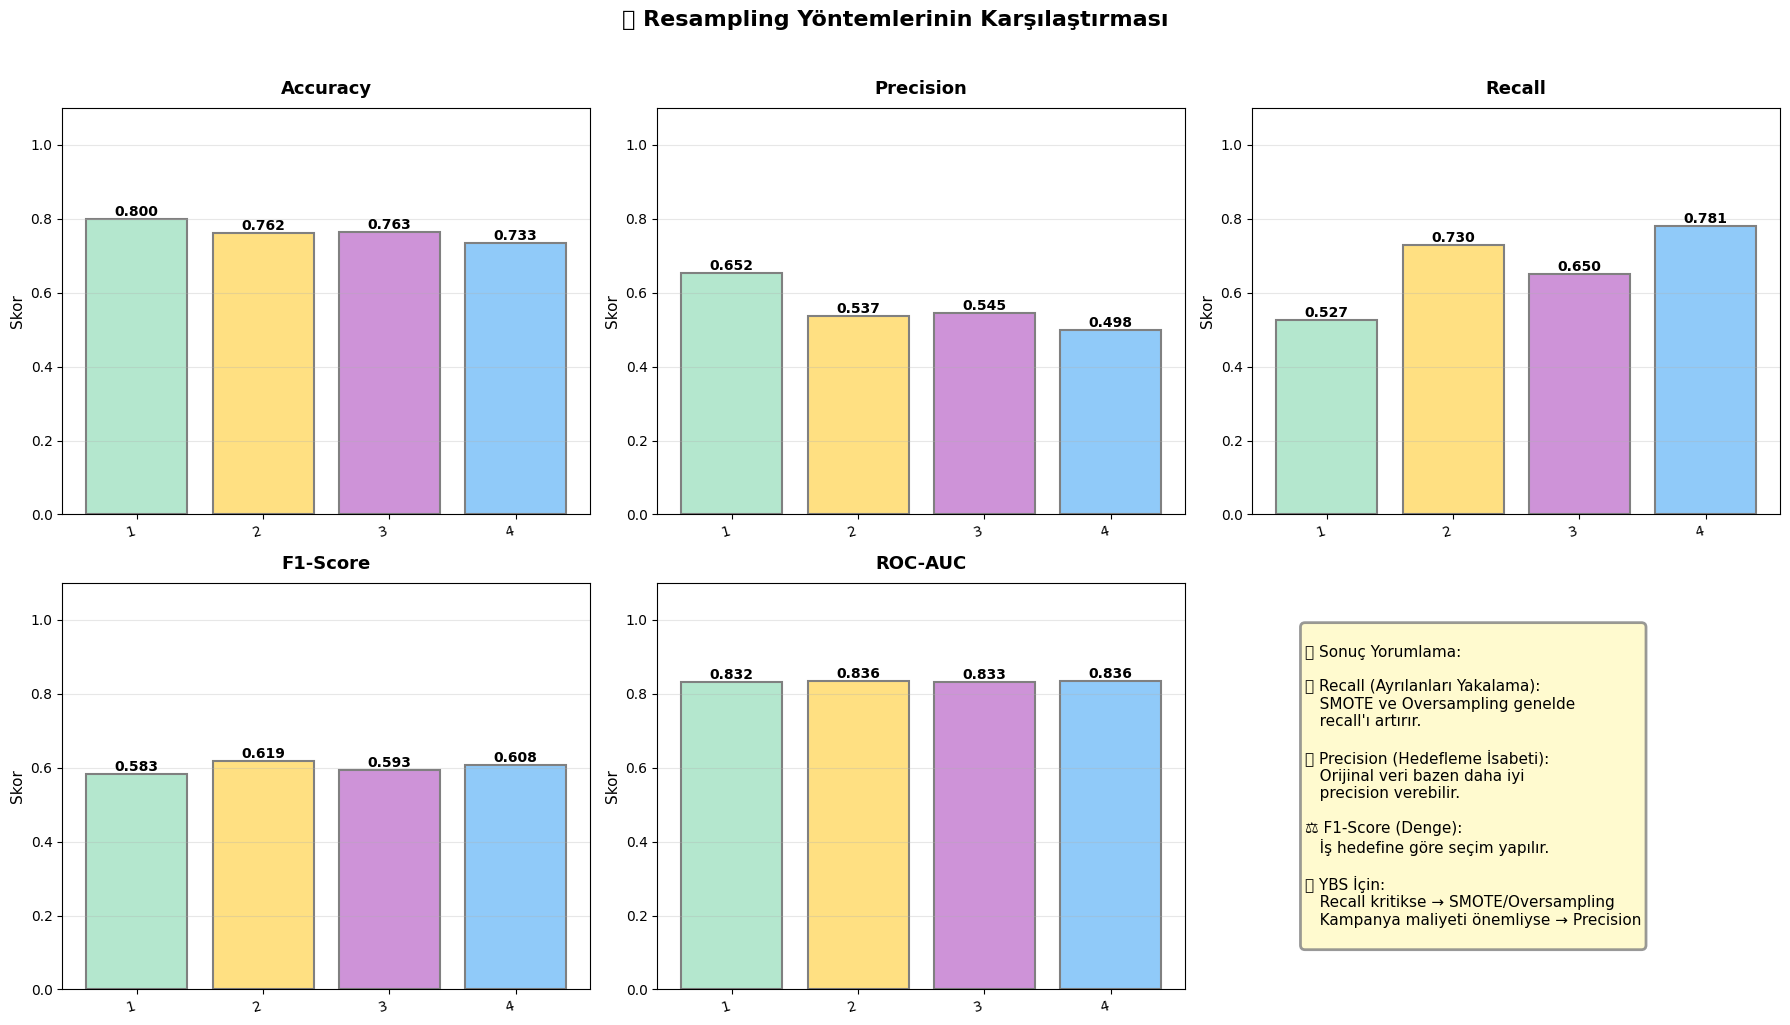

In [30]:
# Sonuçları görselleştir
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔬 Resampling Yöntemlerinin Karşılaştırması', fontsize=16, fontweight='bold', y=1.02)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#B4E7CE', '#FFE082', '#CE93D8', '#90CAF9']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Bar plot
    bars = ax.bar(range(len(results_df)), results_df[metric], color=colors, edgecolor='gray', linewidth=1.5)
    
    # Değerleri bar üzerine yaz
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Başlık ve etiketler
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Skor', fontsize=11)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels([s.split('.')[0] for s in results_df['Senaryo']], rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

# Son subplot'u bilgi paneli olarak kullan
axes[1, 2].axis('off')
info_text = """
📌 Sonuç Yorumlama:

✅ Recall (Ayrılanları Yakalama):
   SMOTE ve Oversampling genelde
   recall'ı artırır.

✅ Precision (Hedefleme İsabeti):
   Orijinal veri bazen daha iyi
   precision verebilir.

⚖️ F1-Score (Denge):
   İş hedefine göre seçim yapılır.

🎯 YBS İçin:
   Recall kritikse → SMOTE/Oversampling
   Kampanya maliyeti önemliyse → Precision
"""

axes[1, 2].text(0.1, 0.5, info_text, fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8, edgecolor='gray', linewidth=2))

plt.tight_layout()
plt.show()

---

## 🎯 **Sonuç ve Öneriler**

### 💡 **Hangi Yöntemi Seçmeliyiz?**

| Durum | Önerilen Yaklaşım | Sebep |
| ------|------------------|-------|
| **Veri az** | SMOTE veya Random Oversampling | Veri kaybı istemiyoruz |
| **Veri çok fazla** | Downsampling | Hız kazanırız, veri kaybı tolere edilebilir |
| **Recall kritik** | SMOTE | Azınlığı daha iyi öğretir |
| **Precision kritik** | Orijinal + Class Weight | Dengeyi model içinde ayarla |
| **Hızlı prototip** | Downsampling | En hızlı eğitim |
| **Production** | SMOTE + Cross-Validation | En güvenli genelleme |

### 📌 **YBS Perspektifinden Ana Çıkarımlar**

1. **Dengesizlik sadece teknik değil, iş problemidir.** Azınlık sınıfı (churn=1) iş maliyeti yüksektir.

2. **Sadece Accuracy'ye güvenmeyin!** Dengesiz veri setlerinde Recall, Precision, F1, ROC-AUC kritiktir.

3. **Test setini doğal bırakın!** Balancing sadece train'de yapılmalı, test gerçek dünyayı temsil etmelidir.

4. **Encoding seçimi performansı etkiler.** One-Hot yorumlanabilir, Target Encoding performanslı ama riskli, Ordinal iş mantığıyla uyumlu olmalı.

5. **"Tek doğru" yoktur.** Her veri seti farklıdır; Orijinal, Oversampling, SMOTE ve Downsampling'i deneyin, metrikleri karşılaştırın.

6. **İş hedefi kararı belirler.** Müşteri kaybı maliyeti yüksekse Recall'ı optimize edin, kampanya bütçesi sınırlıysa Precision'a önem verin.